# Univariate Zeitreihenanalyse — Gold (XAU/USD)

Dieses Notebook analysiert den Goldpreis (Ticker: `GC=F` von Yahoo Finance) im Zeitraum **2015 bis 2025**.

Wir folgen der klassischen **Box-Jenkins-Methodik**, die aus sieben Schritten besteht:

1. **Visuelle Inspektion** — Wie sieht die Zeitreihe aus? Gibt es einen Trend, Saisonalität, Ausreißer?
2. **Stationaritätstest (ADF-Test)** — Ist die Reihe stationär? Das ist eine Grundvoraussetzung für ARIMA.
3. **Differenzierung** — Falls nicht stationär: Reihe differenzieren, bis sie es ist.
4. **ACF & PACF** — Autokorrelation und partielle Autokorrelation analysieren, um die Modellordnung zu bestimmen.
5. **Modellauswahl (p, d, q)** — ARIMA-Parameter auf Basis der vorherigen Schritte wählen.
6. **Residualdiagnostik** — Sind die Residuen des Modells weißes Rauschen?
7. **Prognose** — Zukünftige Werte vorhersagen und Unsicherheitsintervalle berechnen.

Dieses Notebook deckt **alle sieben Schritte** für die Goldzeitreihe ab.

---
## Schritt 1: Visuelle Inspektion

Bevor wir irgendein statistisches Modell aufstellen, schauen wir uns die Zeitreihe zuerst mit eigenen Augen an. Das gibt uns ein erstes Gefühl dafür:

- Gibt es einen **langfristigen Trend** (steigt oder fällt der Preis über die Jahre)?
- Gibt es Phasen mit höherer oder niedrigerer **Volatilität** (breite vs. enge Schwankungen)?
- Gibt es **strukturelle Brüche** — also Zeitpunkte, an denen sich das Verhalten der Reihe plötzlich verändert hat (z.B. durch eine Krise, einen Krieg, eine Zentralbankentscheidung)?

Die visuelle Analyse ist kein optionaler Schritt — sie ist ein zentraler Teil der Box-Jenkins-Methodik.

In [1]:
import sys
import os

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils.data_loader import load_series

In [2]:
# Load the Gold futures series (GC=F)
gold = load_series("GC=F")

[data_loader] Loading cached file: GC_F_2015-01-01_to_2025-05-04.csv


In [3]:
# Basic data overview: types, head, and summary statistics
print("=== Datentypen & Struktur ===")
gold.info()

print("\n=== Erste Zeilen ===")
display(gold.head())

print("\n=== Statistische Kennzahlen ===")
display(gold.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2597 entries, 2015-01-02 to 2025-05-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2597 non-null   float64
 1   High    2597 non-null   float64
 2   Low     2597 non-null   float64
 3   Open    2597 non-null   float64
 4   Volume  2597 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 121.7 KB

=== Erste Zeilen ===


,Close,High,Low,Open,Volume
Price,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92



=== Statistische Kennzahlen ===


,Close,High,Low,Open,Volume
count,2597.000000,2597.000000,2597.000000,2597.000000,2597.000000
mean,1647.375779,1655.239046,1639.381171,1647.148093,5232.058144
std,456.709889,459.674481,453.397554,456.298615,28831.771889
min,1050.800049,1062.000000,1046.199951,1053.699951,0.000000
25%,1266.099976,1270.800049,1260.300049,1266.400024,49.000000
50%,1600.000000,1621.000000,1579.800049,1594.500000,185.000000
75%,1898.599976,1907.699951,1886.099976,1897.300049,574.000000
max,3406.199951,3485.600098,3361.699951,3422.199951,386334.000000


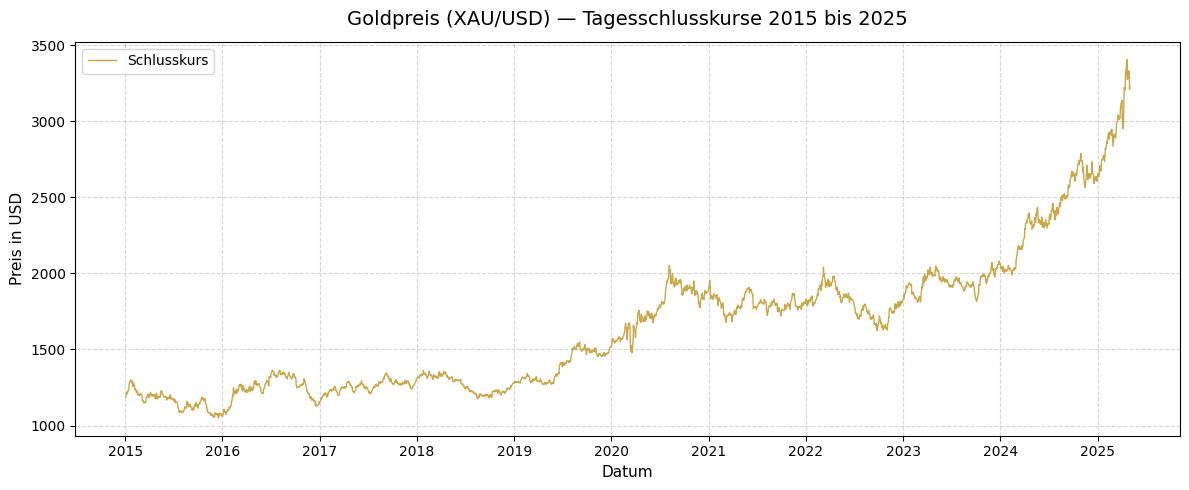

In [4]:
# Plot the daily closing price of Gold over the full sample period
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(gold.index, gold["Close"], color="#C9A84C", linewidth=1.0, label="Schlusskurs")

ax.set_title("Goldpreis (XAU/USD) — Tagesschlusskurse 2015 bis 2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Preis in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# Format x-axis with clean year labels
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

---
## Schritt 2: Stationaritätstest (ADF)

Eine Zeitreihe ist **stationär**, wenn Mittelwert, Varianz und Autokorrelationsstruktur sich über die Zeit nicht verändern. ARIMA setzt Stationarität voraus.

Der **Augmented Dickey-Fuller Test** prüft formal, ob eine Reihe einen sogenannten *Unit Root* (Einheitswurzel) hat:

- **H₀:** Die Reihe hat eine Einheitswurzel → **nicht stationär**
- **H₁:** Die Reihe hat keine Einheitswurzel → **stationär**

Faustregel: **p-Wert < 0,05** → H₀ ablehnen → stationär. \
**p-Wert ≥ 0,05** → nicht stationär → wir müssen differenzieren.

**Erwartetes Ergebnis:** Der Goldpreis hat einen klaren langfristigen Aufwärtstrend — wir erwarten daher, dass die Reihe **nicht stationär** ist.

In [5]:
# Import the shared ADF helper — lives in src/utils/preprocessing.py
# so all team members (Gold, BTC, EUR/USD) can reuse it
from src.utils.preprocessing import adf_test

In [6]:
# Run ADF test on the raw Gold closing price series
result_raw = adf_test(gold["Close"], title="Goldpreis (Close) — Rohdaten")


ADF-Test: Goldpreis (Close) — Rohdaten
  Test Statistic: 1.9621521891521625
  p-value: 0.9986217066706323
  Lags Used: 0
  Observations: 2596
  Kritischer Wert (1%):  -3.4329
  Kritischer Wert (5%):  -2.8627
  Kritischer Wert (10%):  -2.5674

  Ergebnis: NICHT STATIONAER ✗  (p = 0.9986)



---
## Schritt 3: Stationarisierung durch Differenzierung

Der ADF-Test hat gezeigt: Der Goldpreis ist **nicht stationär** (p ≈ 1,00). Um ein ARIMA-Modell anwenden zu können, müssen wir die Reihe stationär machen.

### Erste Differenz

Das einfachste Mittel ist die **erste Differenzierung**:

$$y'_t = y_t - y_{t-1}$$

Statt des absoluten Preises betrachten wir die **tägliche Preisveränderung**. Das entfernt den langfristigen Trend, denn wenn sich der Preis gleichmäßig nach oben bewegt, sind die Abstände zwischen aufeinanderfolgenden Tagen annähernd konstant — und eine konstante Reihe um null ist stationär.

Nach der Differenzierung führen wir **zwei Tests** durch:

- **ADF-Test** — H₀: nicht stationär → wir wollen p < 0,05
- **KPSS-Test** — H₀: stationär → wir wollen p > 0,05 (H₀ *nicht* ablehnen)

Wenn **beide Tests übereinstimmen**, können wir sicher sein, dass d = 1 ausreicht. Der ARIMA-Parameter **d** gibt an, wie oft wir differenzieren müssen — wir erwarten d = 1.

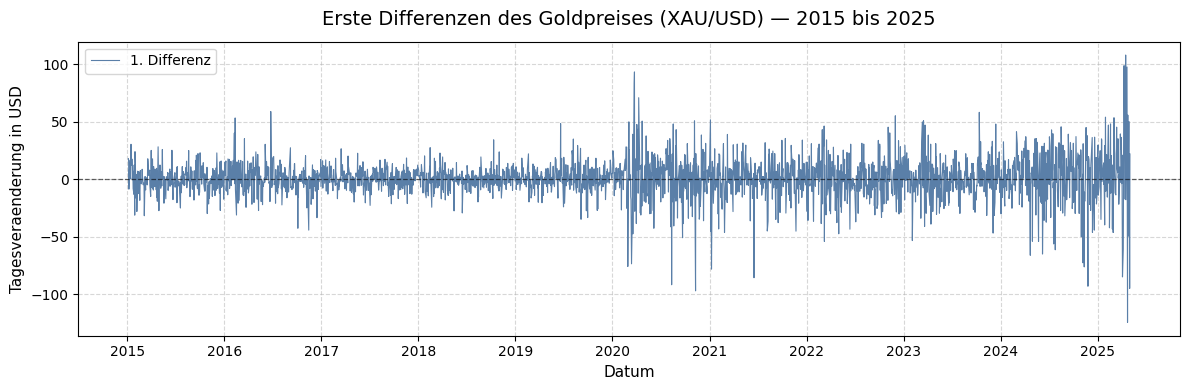

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# First-order differencing: daily price changes
gold_diff = gold["Close"].diff().dropna()

# Plot the differenced series
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(gold_diff.index, gold_diff.values, color="#5A7FA8", linewidth=0.8, label="1. Differenz")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)

ax.set_title("Erste Differenzen des Goldpreises (XAU/USD) — 2015 bis 2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Tagesveraenderung in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Beobachtungen zur differenzierten Reihe

_(Hier kommen Luis' Beobachtungen zur differenzierten Reihe rein)_

In [8]:
from src.utils.preprocessing import adf_test, kpss_test

# ADF test on the differenced series — we expect p < 0.05 (stationary)
result_adf_diff = adf_test(gold_diff, title="Gold (1. Differenz)")

# KPSS test on the differenced series — we expect p > 0.05 (fail to reject H0)
result_kpss_diff = kpss_test(gold_diff, title="Gold (1. Differenz)")


ADF-Test: Gold (1. Differenz)
  Test Statistic: -52.03521283532743
  p-value: 0.0
  Lags Used: 0
  Observations: 2595
  Kritischer Wert (1%):  -3.4329
  Kritischer Wert (5%):  -2.8627
  Kritischer Wert (10%):  -2.5674

  Ergebnis: STATIONAER ✓  (p = 0.0000)


KPSS-Test: Gold (1. Differenz)
  Test Statistic: 0.5544259556858718
  p-value: 0.02940856853921805
  Lags Used: 7
  Kritischer Wert (10%):  0.3470
  Kritischer Wert (5%):  0.4630
  Kritischer Wert (2.5%):  0.5740
  Kritischer Wert (1%):  0.7390

  Ergebnis: NICHT STATIONAER ✗  (p = 0.0294)



### Interpretation der Testergebnisse

Die beiden Tests testen gewissermaßen aus **entgegengesetzten Richtungen**:

| Test | H₀ (Nullhypothese) | Stationaritaet bestaetigt, wenn... |
|------|--------------------|------------------------------------|
| **ADF** | Reihe hat Einheitswurzel (nicht stationaer) | p-Wert **< 0,05** (H₀ ablehnen) |
| **KPSS** | Reihe ist stationaer | p-Wert **> 0,05** (H₀ *nicht* ablehnen) |

#### Ergebnisse fuer Gold (1. Differenz)

| Test | Teststatistik | p-Wert | Ergebnis |
|------|---------------|--------|----------|
| ADF  | -52,04 | p ≈ 0,000 | STATIONAER ✓ |
| KPSS | 0,554  | p = 0,029 | NICHT STATIONAER ✗ |

#### Was bedeutet diese Diskrepanz?

Die beiden Tests widersprechen sich leicht — das ist bei Finanz-Zeitreihen nicht ungewoehnlich und hat eine konkrete Ursache:

Der ADF-Test prueft, ob ein **langfristiger Trend (Unit Root)** vorliegt. Das tut er nach der Differenzierung klar nicht mehr (p ≈ 0).

Der KPSS-Test schlaegt dennoch an, weil er auf **zeitlich variierende Varianz** reagiert. Im differenzierten Goldpreis sieht man, dass ruhige Phasen (z.B. 2015-2018) und turbulente Phasen (z.B. 2020, 2024) abwechseln — die Schwankungsbreite ist nicht konstant. Dieses Phaenomen heißt **Heteroskedastizitaet** (ARCH/GARCH-Effekte).

**Fazit fuer unser ARIMA-Modell:** Der KPSS-Wert (0,554) liegt knapp ueber dem 5%-Schwellenwert (0,463) — es ist ein Grenzfall, kein klares Signal. Der ADF-Test mit p ≈ 0 und einer Teststatistik von -52 ist sehr eindeutig. Fuer die Box-Jenkins-Methodik reicht das: **d = 1** ist ausreichend. Die Heteroskedastizitaet koennte spaeter mit einem GARCH-Modell adressiert werden — das ist jedoch ein separater Schritt jenseits von ARIMA.

---
## Schritt 3.5: Robustness Check — Strukturbrüche

Auf Empfehlung von Prof. Menden untersuchen wir, ob sichtbare **Strukturbrüche** im Goldpreis dazu führen sollten, die Analyse auf einen Teilzeitraum zu beschränken.

Kandidaten für Strukturbrüche im Beobachtungszeitraum 2015–2025:

- **März 2020** — Corona-Schock: Goldpreis bricht kurzfristig ein, erholt sich schnell und schießt dann auf ein neues Allzeithoch
- **Februar 2022** — Russlands Invasion der Ukraine: geopolitische Unsicherheit treibt den Goldpreis schlagartig nach oben

Wir gehen in vier Schritten vor:

1. Visuelle Markierung der Bruchpunkte im Preischart
2. **Chow-Test** am Corona-Bruchpunkt (Februar 2020) auf der differenzierten Reihe
3. **ADF-Test** auf den Teilstichproben (Pre- und Post-Corona)
4. Methodische Entscheidung: vollständige Reihe oder Subsample?

**Vorwegnahme:** Wir werden uns für die vollständige Reihe entscheiden — die Begründung steht am Ende dieser Sektion.

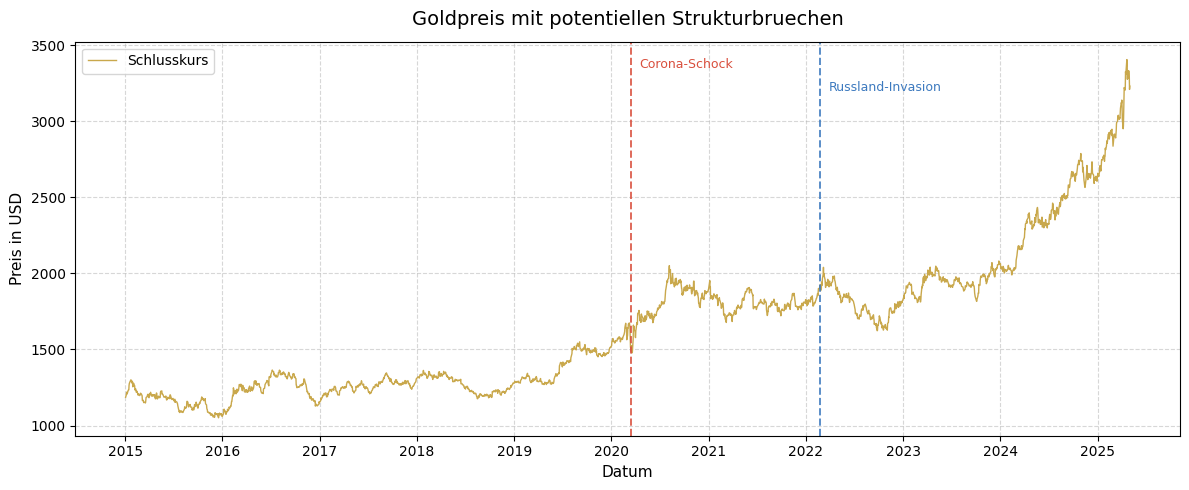

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Replot the Gold closing price with structural break markers overlaid
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(gold.index, gold["Close"], color="#C9A84C", linewidth=1.0, label="Schlusskurs")

# Mark the two candidate break dates with vertical dashed lines
breaks = {
    "2020-03-15": ("Corona-Schock",     "top",    "#D94F3D"),
    "2022-02-24": ("Russland-Invasion", "bottom",  "#3D7ABF"),
}
for date_str, (label, va, color) in breaks.items():
    xval = pd.Timestamp(date_str)
    ax.axvline(xval, color=color, linewidth=1.4, linestyle="--", alpha=0.85)
    ax.annotate(
        label,
        xy=(xval, ax.get_ylim()[1]),
        xytext=(6, -12 if va == "top" else -28),
        textcoords="offset points",
        fontsize=9,
        color=color,
        va="top",
    )

ax.set_title("Goldpreis mit potentiellen Strukturbruechen", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Preis in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import statsmodels.api as sm
from scipy import stats

# --- Chow Test on the first-differenced Gold series at the Corona break point ---
# We test whether the mean daily return shifted significantly after March 2020.

break_date = "2020-03-15"

# Full sample
y_full = gold_diff.dropna().values
n      = len(y_full)
k      = 1  # one parameter: the intercept (constant-only model)

X_const = sm.add_constant(np.ones(n))
rss_full = sm.OLS(y_full, X_const).fit().ssr

# Pre-break subsample
y_pre   = gold_diff.loc[:break_date].dropna().values
X_pre   = sm.add_constant(np.ones(len(y_pre)))
rss_pre = sm.OLS(y_pre, X_pre).fit().ssr

# Post-break subsample
y_post   = gold_diff.loc[break_date:].dropna().values
X_post   = sm.add_constant(np.ones(len(y_post)))
rss_post = sm.OLS(y_post, X_post).fit().ssr

# Chow F-statistic
rss_restricted   = rss_full
rss_unrestricted = rss_pre + rss_post
chow_f = ((rss_restricted - rss_unrestricted) / k) / (rss_unrestricted / (n - 2 * k))
p_val  = stats.f.sf(chow_f, k, n - 2 * k)

print("=" * 55)
print(f"Chow-Test — Bruchpunkt: {break_date}")
print("=" * 55)
print(f"  Beobachtungen gesamt : {n}")
print(f"  Beobachtungen Pre    : {len(y_pre)}")
print(f"  Beobachtungen Post   : {len(y_post)}")
print(f"  RSS (vollstaendig)   : {rss_restricted:,.2f}")
print(f"  RSS (Pre + Post)     : {rss_unrestricted:,.2f}")
print(f"  F-Statistik          : {chow_f:.4f}")
print(f"  p-Wert               : {p_val:.4f}")
print(f"  Bruch signifikant bei alpha=0.05: {'JA' if p_val < 0.05 else 'NEIN'}")
print("=" * 55)

Chow-Test — Bruchpunkt: 2020-03-15
  Beobachtungen gesamt : 2596
  Beobachtungen Pre    : 1304
  Beobachtungen Post   : 1292
  RSS (vollstaendig)   : 750,364.00
  RSS (Pre + Post)     : 749,613.33
  F-Statistik          : 2.5977
  p-Wert               : 0.1071
  Bruch signifikant bei alpha=0.05: NEIN


In [11]:
from src.utils.preprocessing import adf_test

# Split the differenced series at the Corona break date
pre_diff  = gold_diff.loc[:"2020-03-14"]
post_diff = gold_diff.loc["2020-03-15":]

print(f"Pre-Corona  : {len(pre_diff):,} Beobachtungen ({pre_diff.index[0].date()} bis {pre_diff.index[-1].date()})")
print(f"Post-Corona : {len(post_diff):,} Beobachtungen ({post_diff.index[0].date()} bis {post_diff.index[-1].date()})\n")

# ADF on each sub-sample — both should confirm stationarity
result_pre  = adf_test(pre_diff,  title="Gold (1. Diff.) — Pre-Corona")
result_post = adf_test(post_diff, title="Gold (1. Diff.) — Post-Corona")

Pre-Corona  : 1,304 Beobachtungen (2015-01-05 bis 2020-03-13)
Post-Corona : 1,292 Beobachtungen (2020-03-16 bis 2025-05-02)


ADF-Test: Gold (1. Diff.) — Pre-Corona
  Test Statistic: -15.892820255897615
  p-value: 8.50191224712183e-29
  Lags Used: 4
  Observations: 1299
  Kritischer Wert (1%):  -3.4354
  Kritischer Wert (5%):  -2.8638
  Kritischer Wert (10%):  -2.5680

  Ergebnis: STATIONAER ✓  (p = 0.0000)


ADF-Test: Gold (1. Diff.) — Post-Corona
  Test Statistic: -37.234373760494
  p-value: 0.0
  Lags Used: 0
  Observations: 1291
  Kritischer Wert (1%):  -3.4354
  Kritischer Wert (5%):  -2.8638
  Kritischer Wert (10%):  -2.5680

  Ergebnis: STATIONAER ✓  (p = 0.0000)



### Fazit: Vollständige Reihe oder Subsample?

**Chow-Test-Ergebnis:** F = 2,60, p = 0,107 — der Bruch ist bei alpha = 0,05 **nicht signifikant**. Die täglichen Kursveränderungen (gold_diff) zeigen vor und nach dem Corona-Schock statistisch keinen unterschiedlichen datengenerierenden Prozess. Der visuelle Eindruck eines Bruchs erklärt sich durch erhöhte Volatilität, nicht durch eine Verschiebung des durchschnittlichen Tagesprozesses.

**Beide Teilstichproben sind stationär** (ADF Pre: p ≈ 0, ADF Post: p ≈ 0) — der Bruch betrifft das Preisniveau, nicht die stochastische Struktur der Differenzen.

**Wir entscheiden uns, mit der vollständigen Reihe weiterzuarbeiten.**

Begründung:

- **Chow-Test nicht signifikant:** Es gibt keinen statistischen Zwang zum Subsample.
- **Mehr Datenpunkte = stabilere Parameterschätzung.** Mit 2.597 Beobachtungen schätzen wir die ARIMA-Parameter auf einer breiten empirischen Basis.
- **ARIMA modelliert den durchschnittlichen datengenerierenden Prozess.** Ein kurzer Schock verändert die serielle Abhängigkeitsstruktur nicht dauerhaft.
- **Ein reines Post-Corona-Modell hätte nur ~1.300 Beobachtungen**, was für robuste ARIMA-Schätzung (insbesondere für die Selektion via AIC) knapp ist.
- **Der Strukturbruch wird in der Residuenanalyse sichtbar sein** — wir thematisieren ihn dort erneut und dokumentieren ihn transparent.

---

> Diese Robustness-Sektion dient der methodischen Transparenz. Im Hauptmodell verwenden wir weiterhin den vollen Zeitraum 2015–2025.

---
## Schritt 4: ACF und PACF — Modellidentifikation

Wir haben jetzt eine stationäre Reihe (gold_diff, d = 1) und keinen signifikanten Strukturbruch gefunden. Der nächste Schritt ist die **Identifikation der ARIMA-Ordnungen p und q** mithilfe der Autokorrelations- und partiellen Autokorrelationsfunktion.

### Was zeigen ACF und PACF?

- **ACF (Autokorrelationsfunktion):** Wie stark korreliert der Wert zum Zeitpunkt t mit dem Wert zum Zeitpunkt t-k — für alle Lags k = 1, 2, …, 40? Das beinhaltet auch indirekte Effekte über zwischenliegende Lags.
- **PACF (Partielle Autokorrelationsfunktion):** Wie stark ist die *direkte* Korrelation zwischen t und t-k, nachdem der Einfluss aller dazwischenliegenden Lags herausgerechnet wurde?
- **Blaues Konfidenzband (95%):** Lags innerhalb des Bandes gelten als statistisch nicht signifikant — wir ignorieren sie bei der Modellwahl.

### Entscheidungsregeln

| Muster | Interpretation |
|--------|---------------|
| ACF bricht nach Lag q ab, PACF klingt langsam ab | → MA(q) |
| PACF bricht nach Lag p ab, ACF klingt langsam ab | → AR(p) |
| Beide klingen langsam ab | → ARMA(p, q) |
| Beide nahezu null ab Lag 1 | → White Noise, kein ARMA nötig |

**Caveat bei Finanzdaten:** Die Markteffizienz-Hypothese besagt, dass vergangene Preise keine nützliche Information über künftige Preise enthalten. In der Praxis sind bei täglichen Renditen daher oft nur wenige Lags (1–2) signifikant oder gar keine.

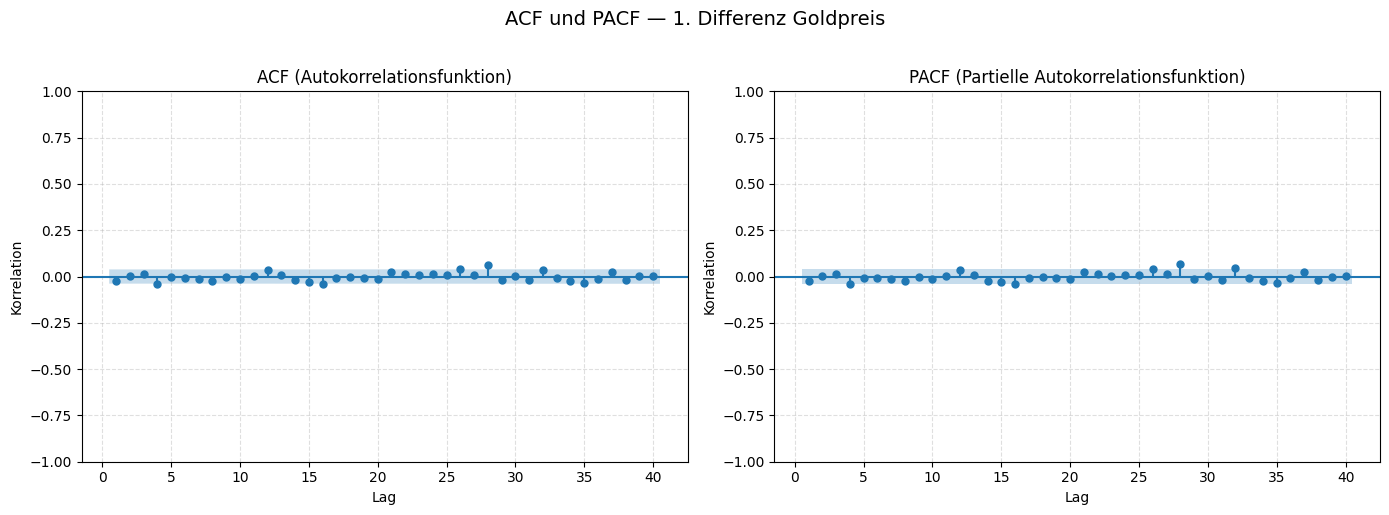

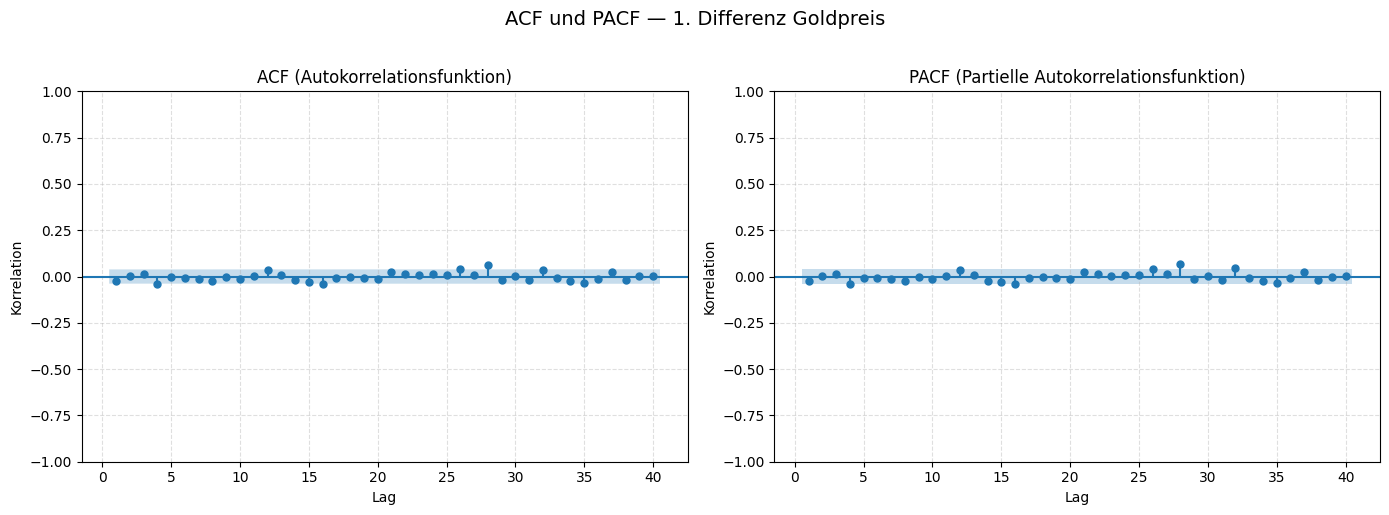

In [12]:
from src.utils.preprocessing import plot_acf_pacf

# Plot ACF and PACF of the first-differenced Gold series
plot_acf_pacf(
    gold_diff,
    lags=40,
    title="ACF und PACF — 1. Differenz Goldpreis",
)

## Interpretation

_(Hier kommt Luis' Interpretation der ACF/PACF rein — wir besprechen das gemeinsam.)_

### Modellkandidaten für Schritt 5

Auf Basis der ACF/PACF sowie typischer Muster bei täglichen Finanzrenditen vergleichen wir folgende Kandidaten:

| Modell | Bedeutung |
|--------|-----------|
| **ARIMA(0,1,0)** | Random Walk — jeder Tag ist unabhängig vom vorherigen; wichtige Benchmark (Markteffizienz) |
| **ARIMA(1,1,0)** | AR(1) auf den Differenzen — gestern beeinflusst heute direkt |
| **ARIMA(0,1,1)** | MA(1) auf den Differenzen — gestern Schock beeinflusst heute noch |
| **ARIMA(1,1,1)** | Kombiniertes ARMA(1,1) — sowohl AR- als auch MA-Komponente |
| **ARIMA(2,1,2)** | Etwas komplexeres Modell — nur sinnvoll, wenn ACF/PACF mehrere signifikante Lags zeigt |

Diese Liste passen wir nach der gemeinsamen Inspektion der Plots ggf. an.

---
## Schritt 5: Modellvergleich und -auswahl

Wir haben d = 1 festgelegt und aus ACF/PACF mögliche Kandidaten abgeleitet. Jetzt passen wir diese Modelle an die Daten an und vergleichen sie anhand von zwei Informationskriterien.

### AIC und BIC

Beide Kriterien bewerten die Modellgüte — aber sie bestrafen Komplexität unterschiedlich:

| Kriterium | Formel (vereinfacht) | Tendenz |
|-----------|----------------------|---------|
| **AIC** (Akaike) | -2 · log L + 2 · k | Bevorzugt etwas komplexere Modelle |
| **BIC** (Bayesian) | -2 · log L + k · ln(n) | Stärker gegen Überanpassung |

- Niedrigerer Wert = besseres Modell
- **k** = Anzahl der Parameter, **n** = Anzahl der Beobachtungen, **L** = Likelihood
- Bei großen Stichproben (hier n ≈ 2.600) bestraft BIC Extraparameter deutlich stärker

**Warnsignale für Überanpassung:**
- Koeffizienten mit hohem p-Wert (> 0,05) → Parameter tragen nicht zur Erklärung bei
- AIC-Gewinner hat viele mehr Parameter als BIC-Gewinner → Hinweis auf Überanpassung

In [13]:
import warnings
warnings.filterwarnings("ignore")  # suppress statsmodels date-frequency warnings

from src.models.arima import compare_models

candidates = [(0,1,0), (1,1,0), (0,1,1), (1,1,1), (2,1,2)]
results = compare_models(gold["Close"], candidates)

# Display full comparison table
results[["model","AIC","BIC","log_likelihood","n_params","converged","notes"]]

,model,AIC,BIC,log_likelihood,n_params,converged,notes
0,"ARIMA(2, 1, 2)",22065.43,22094.74,-11027.72,6,True,
1,"ARIMA(0, 1, 1)",22069.20,22080.92,-11032.60,3,True,
2,"ARIMA(1, 1, 1)",22071.18,22088.76,-11032.59,4,True,
3,"ARIMA(0, 1, 0)",22076.55,22082.41,-11037.27,2,True,
4,"ARIMA(1, 1, 0)",22077.55,22089.27,-11036.78,3,True,


## Interpretation des Modellvergleichs

_(Hier kommt Luis' Interpretation rein — wir besprechen die Tabelle gemeinsam.)_

In [14]:
import warnings
warnings.filterwarnings("ignore")

from src.models.arima import fit_arima

# Methodological choice (Option C — see discussion above):
# - ARIMA(0,1,1) as main model: BIC winner, parsimonious, MA(1) significant
# - ARIMA(0,1,0) as theoretical benchmark: pure Random Walk, theoretically
#   consistent with the Efficient Market Hypothesis and our ACF/PACF diagnosis
main_model      = fit_arima(gold["Close"], order=(0, 1, 1))
benchmark_model = fit_arima(gold["Close"], order=(0, 1, 0))

print("=" * 60)
print("Hauptmodell: ARIMA(0,1,1) — BIC-Sieger")
print("=" * 60)
print(main_model.summary())
print()
print("=" * 60)
print("Benchmark-Modell: ARIMA(0,1,0) — Random Walk")
print("=" * 60)
print(benchmark_model.summary())

Hauptmodell: ARIMA(0,1,1) — BIC-Sieger
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2597
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -11032.599
Date:                Sun, 10 May 2026   AIC                          22069.198
Time:                        18:36:20   BIC                          22080.920
Sample:                             0   HQIC                         22073.446
                               - 2597                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0199      0.013     -1.563      0.118      -0.045       0.005
sigma2       289.7464      3.970     72.982      0.000     281.965     297.528
Ljung-Box (L1

### Methodische Entscheidung: Option C — Vergleich gegen Markteffizienz-Benchmark

Auf Basis des Modellvergleichs treffen wir eine bewusste methodische Entscheidung (**Option C — Vergleich gegen Markteffizienz-Benchmark**):

- **Hauptmodell:** ARIMA(0,1,1) — BIC-Sieger, sparsamste Spezifikation mit signifikanten Koeffizienten
- **Benchmark:** ARIMA(0,1,0) — der reine Random Walk als theoretisch fundierter Vergleichsmaßstab. In einem effizienten Markt sollte kein ARMA-Modell den Random Walk substantiell schlagen

**Warum nicht ARIMA(2,1,2)?** Obwohl es den niedrigsten AIC hat, sind `ar.L1` (p = 0,38) und `ma.L1` (p = 0,41) nicht signifikant. Das Modell erkauft sich eine minimale AIC-Verbesserung von ~4 Punkten mit 3 Extraparametern, von denen die Hälfte statistisch nutzlos ist. Das ist ein klares Zeichen von Überanpassung.

Wir führen **beide Modelle** durch alle nachfolgenden Schritte (Residuendiagnostik, Forecast) und prüfen am Ende, ob ARIMA(0,1,1) einen praktisch relevanten Mehrwert gegenüber dem Random-Walk-Benchmark liefert.

---
## Schritt 6: Residuendiagnostik

Ein ARIMA-Modell ist nur dann gut spezifiziert, wenn seine **Residuen wie weißes Rauschen aussehen** — d.h. wenn das Modell alle systematischen Muster aus den Daten extrahiert hat und nur unvorhersehbares Rauschen übrig bleibt.

**Was sind Residuen?**

$$\text{Residuum}_t = y_t - \hat{y}_t$$

Der Unterschied zwischen dem tatsächlichen Wert und dem vom Modell vorhergesagten Wert. Wenn das Modell gut ist, sollten diese Abweichungen zufällig und unkorreliert sein.

**Fünf Checks:**

| Check | Was wir prüfen | Gewünschtes Ergebnis |
|-------|----------------|----------------------|
| Zeitreihenplot | Keine Trends, keine Volatilitäts-Cluster | Zufällig um null |
| Histogramm + Normalverteilung | Glockenform? | Annähernd symmetrisch |
| QQ-Plot | Punkte nahe der Diagonale? | Punkte auf der Linie |
| ACF der Residuen | Keine signifikanten Lags | Alle im Konfidenzband |
| Ljung-Box-Test | Formaler Test auf Autokorrelation | p > 0,05 |
| Jarque-Bera-Test | Formaler Test auf Normalverteilung | p > 0,05 (oft verletzt) |

> **Wichtiger Hinweis:** Bei Finanzdaten erwarten wir, dass der Jarque-Bera-Test Normalität **ablehnt** — Heavy Tails (schwere Ränder) sind eine bekannte Eigenschaft von Finanzrenditen. Das ist kein Modellfehler. Entscheidender ist die **Abwesenheit von Autokorrelation** (Ljung-Box). Außerdem werden wir wahrscheinlich **Volatilitäts-Cluster** in den Residuen sehen — ruhige Phasen wechseln sich mit turbulenten ab. Das ist eine bekannte Limitation von ARIMA, die mit einem **GARCH-Modell** adressierbar wäre, aber ausserhalb des Rahmens dieser Analyse liegt.

### 6.1 Hauptmodell ARIMA(0,1,1)

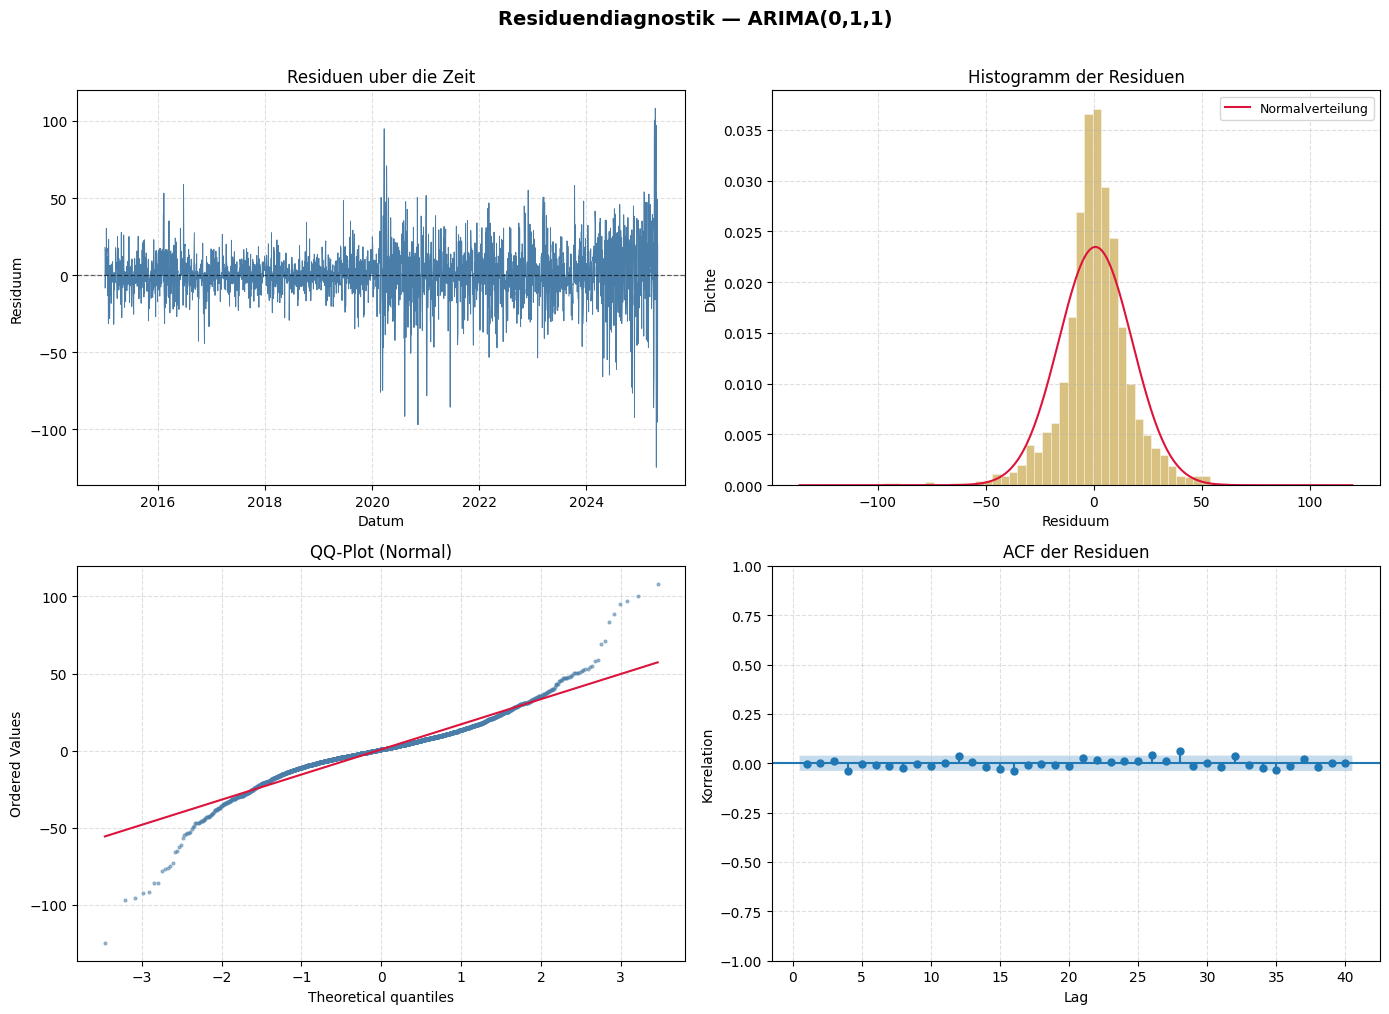

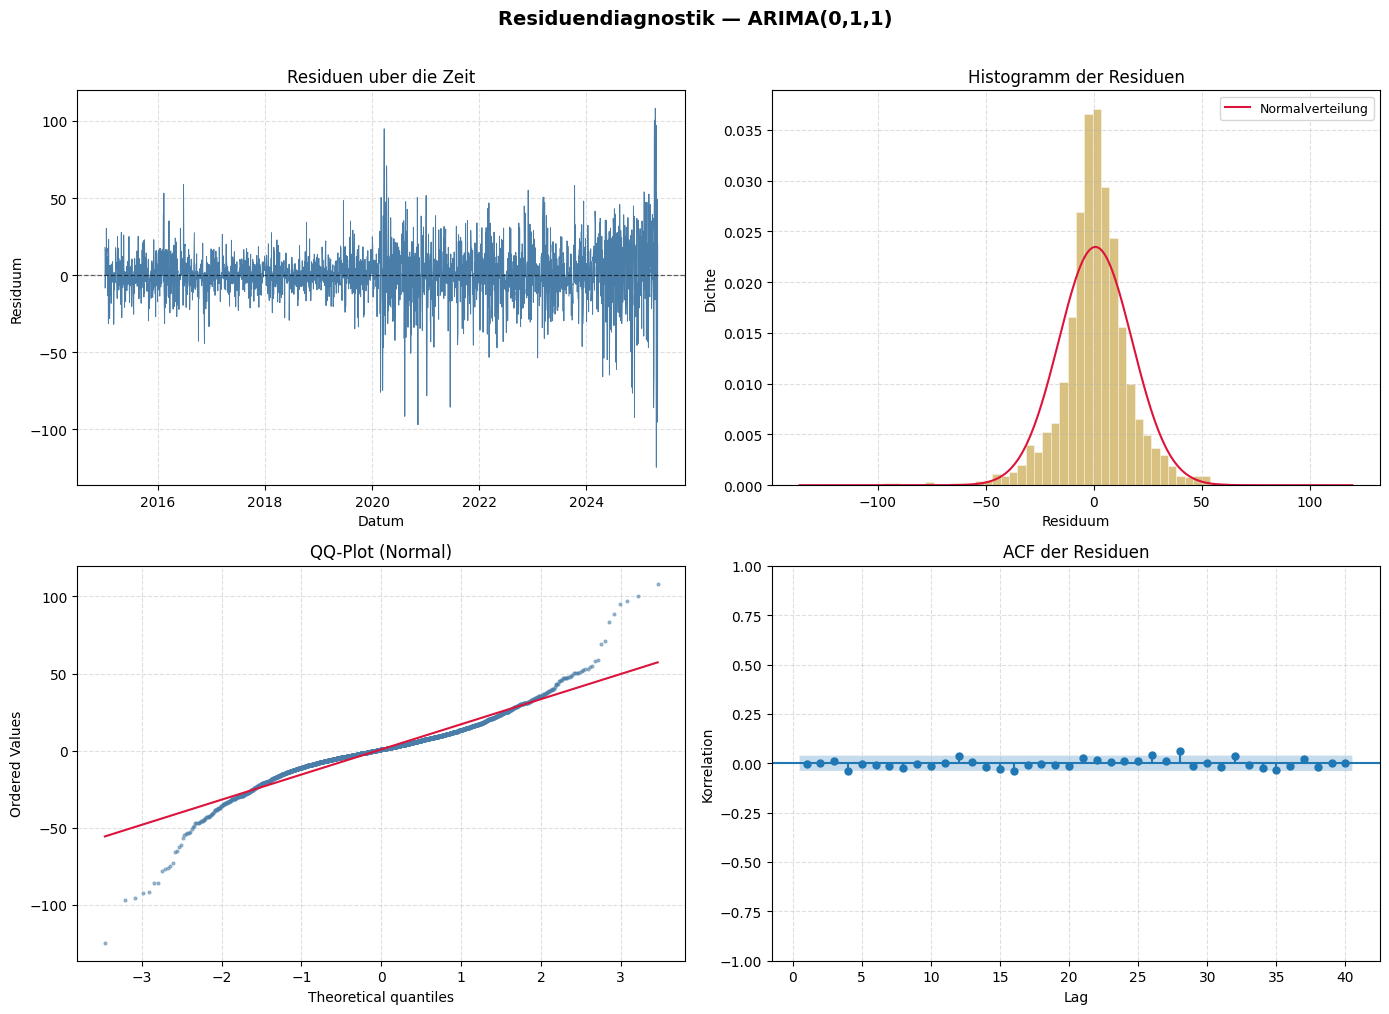

In [15]:
from src.models.arima import plot_residual_diagnostics

# 2x2 diagnostic panel for the main model
plot_residual_diagnostics(main_model, title="Residuendiagnostik — ARIMA(0,1,1)")

In [16]:
from src.models.arima import residual_diagnostics

# Formal statistical tests on the main model residuals
diag_main = residual_diagnostics(main_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =   7.0092,  p = 0.7246  (nicht signifikant ✓)
  Lag 20:  Q =  19.7521,  p = 0.4735  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 4739.2652
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :     0.8038
  Standardabweichung:    17.0005
  Schiefe (Skew)    :    -0.2927
  Excess Kurtosis   :     6.5933  (Normalverteilung = 0)



_(Hier kommt Luis' Interpretation der Residuendiagnostik fuer ARIMA(0,1,1) rein — wir besprechen das gemeinsam.)_

### 6.2 Benchmark ARIMA(0,1,0) — Random Walk

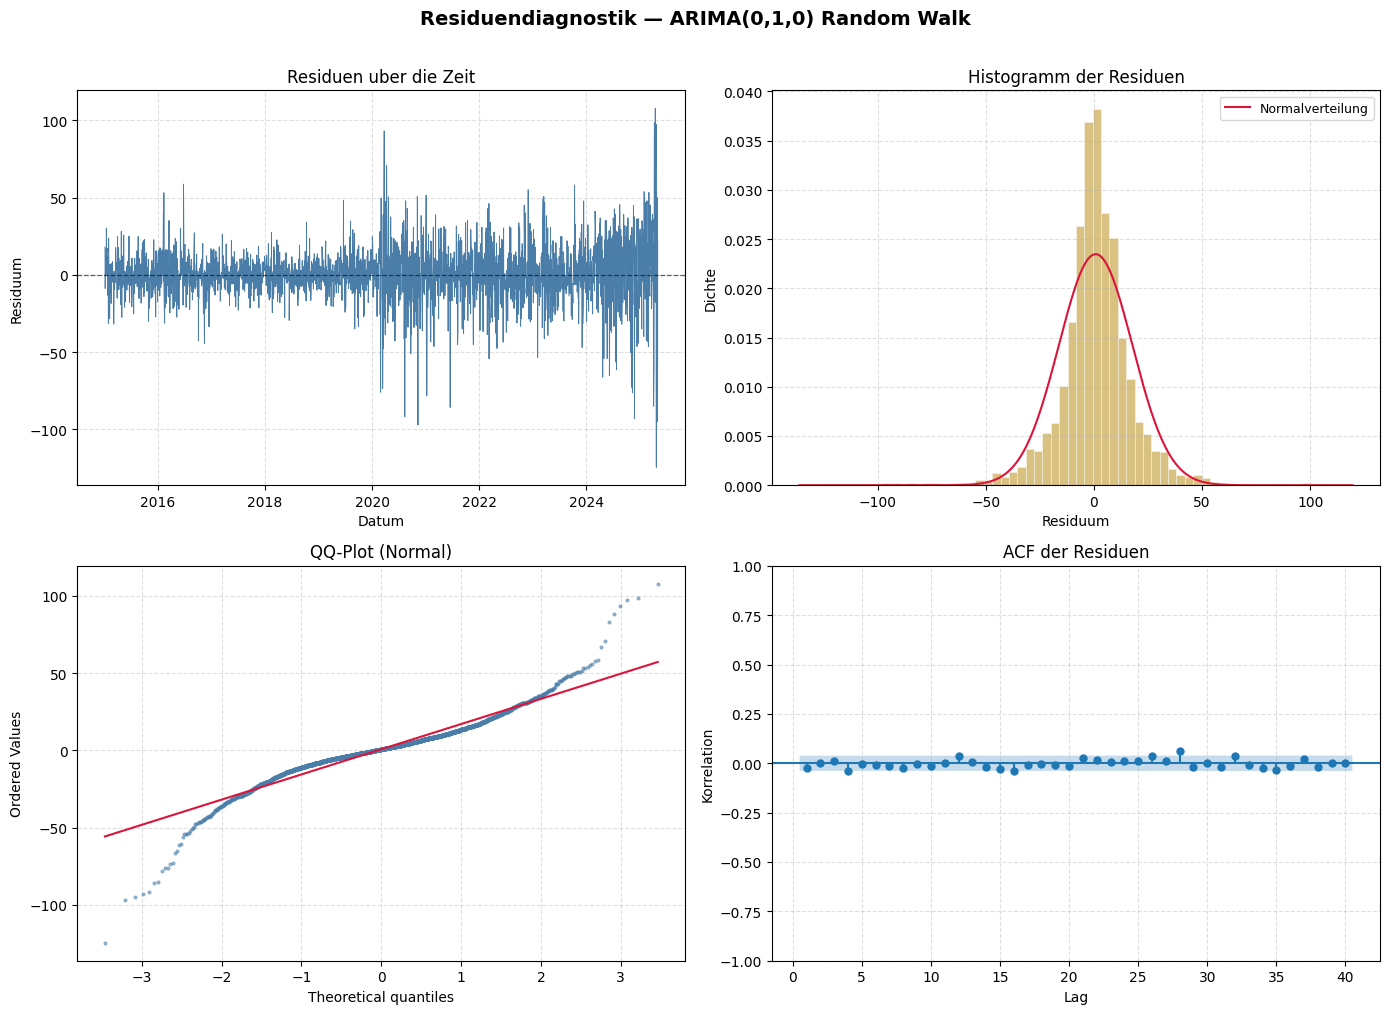

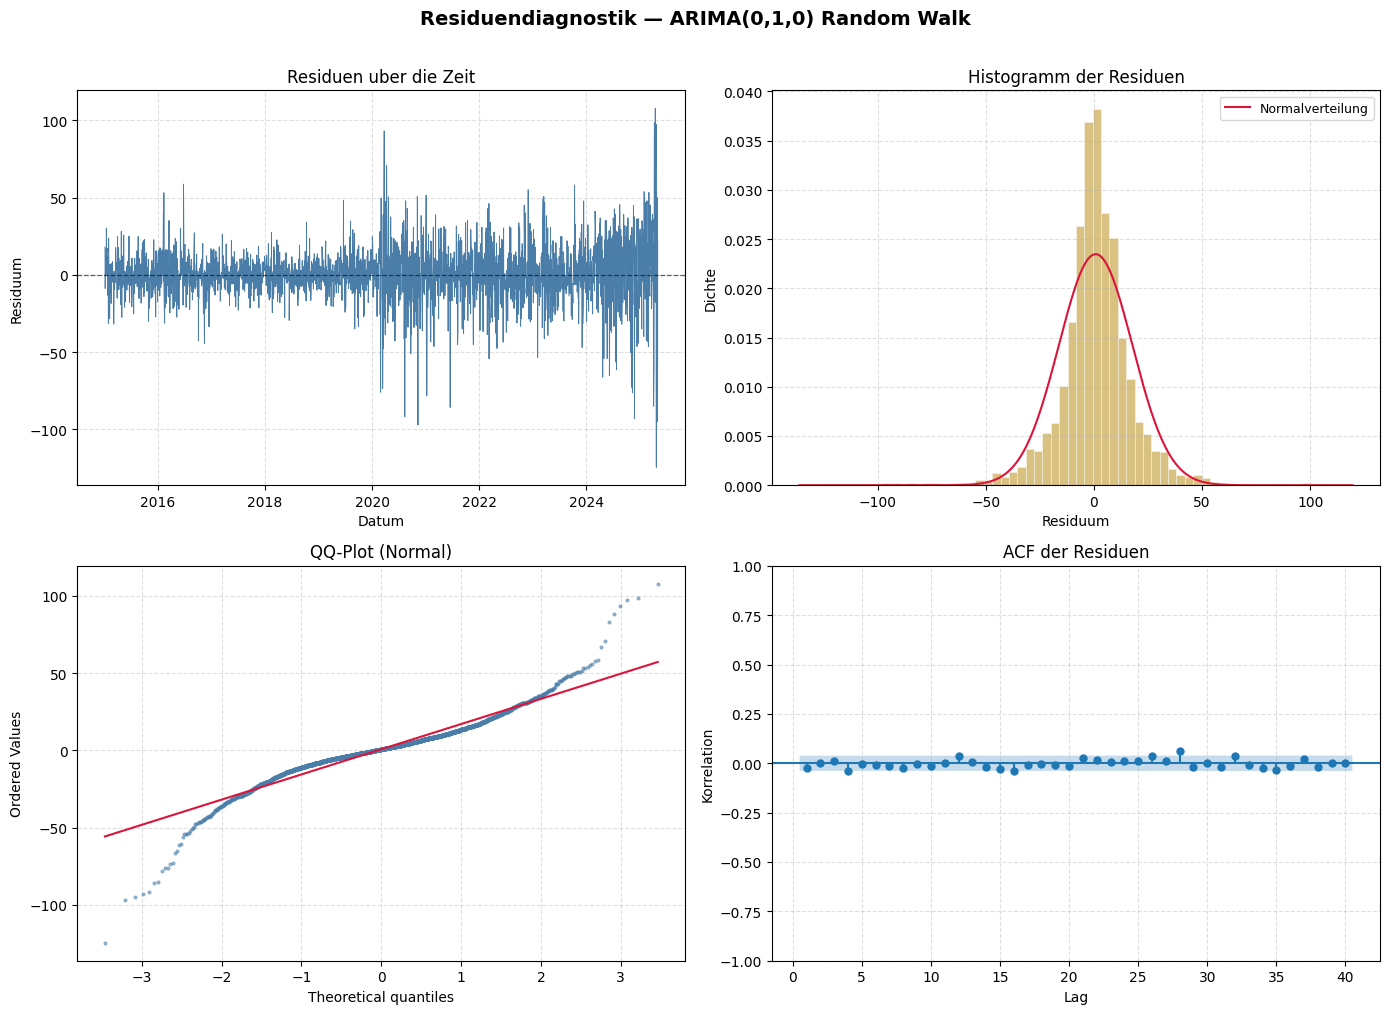

In [17]:
# 2x2 diagnostic panel for the benchmark model
plot_residual_diagnostics(benchmark_model, title="Residuendiagnostik — ARIMA(0,1,0) Random Walk")

In [18]:
# Formal statistical tests on the benchmark model residuals
diag_bench = residual_diagnostics(benchmark_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =   8.1414,  p = 0.6150  (nicht signifikant ✓)
  Lag 20:  Q =  20.3707,  p = 0.4350  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 4640.9634
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :     0.7881
  Standardabweichung:    17.0046
  Schiefe (Skew)    :    -0.3009
  Excess Kurtosis   :     6.5225  (Normalverteilung = 0)



_(Hier kommt Luis' Interpretation der Residuendiagnostik fuer ARIMA(0,1,0) rein.)_

### 6.3 Direkter Vergleich

In [19]:
import pandas as pd

# Side-by-side comparison of both models' residual diagnostics
comparison = pd.DataFrame({
    "ARIMA(0,1,1)": [
        diag_main["lb_p_lag10"],
        diag_main["lb_p_lag20"],
        diag_main["jb_p"],
        diag_main["mean"],
        diag_main["std"],
        diag_main["skew"],
        diag_main["kurtosis"],
    ],
    "ARIMA(0,1,0)": [
        diag_bench["lb_p_lag10"],
        diag_bench["lb_p_lag20"],
        diag_bench["jb_p"],
        diag_bench["mean"],
        diag_bench["std"],
        diag_bench["skew"],
        diag_bench["kurtosis"],
    ],
}, index=[
    "Ljung-Box p (Lag 10)",
    "Ljung-Box p (Lag 20)",
    "Jarque-Bera p",
    "Mittelwert",
    "Standardabweichung",
    "Schiefe (Skew)",
    "Excess Kurtosis",
])

comparison.style.format("{:.4f}")

,"ARIMA(0,1,1)","ARIMA(0,1,0)"
Ljung-Box p (Lag 10),0.7246,0.6150
Ljung-Box p (Lag 20),0.4735,0.4350
Jarque-Bera p,0.0000,0.0000
Mittelwert,0.8038,0.7881
Standardabweichung,17.0005,17.0046
Schiefe (Skew),-0.2927,-0.3009
Excess Kurtosis,6.5933,6.5225


### 6.4 Fazit zu Schritt 6

_(Hier kommt Luis' zusammenfassende Bewertung beider Modelle rein.)_

## Erste Beobachtungen

Gold zeigt insgesamt einen klaren langfristigen Aufwärtstrend. Zwischen 2015 und 2025 steigt der Preis ungefähr von 1.200 USD auf rund 2.800 USD und hat sich damit mehr als verdoppelt. Schon beim ersten Blick auf den Chart erkennt man, dass die Zeitreihe nicht stationär ist.

Von 2015 bis etwa 2018 bewegt sich Gold eher seitwärts. Der Preis schwankt in dieser Phase hauptsächlich zwischen ungefähr 1.050 und 1.350 USD, ohne einen wirklich starken Trend nach oben oder unten.

Der erste große Anstieg kommt dann 2019 bis 2020. Besonders während der COVID-19-Krise steigt Gold stark an und erreicht im August 2020 ein damaliges Allzeithoch von ungefähr 2.050 USD. Das passt gut zur Rolle von Gold als sogenannter „Safe Haven“, also als sicherer Hafen in unsicheren Zeiten.

Danach folgt zwischen 2021 und 2022 wieder ein deutlicher Rückgang. Der Preis fällt teilweise auf etwa 1.600 USD zurück. Ein möglicher Grund dafür sind die steigenden Zinsen in diesem Zeitraum, weil Gold selbst keine laufende Rendite abwirft und dadurch im Vergleich zu verzinsten Anlagen weniger attraktiv wird.

Ab Ende 2022 startet dann die nächste starke Rally. Der Goldpreis steigt fast durchgehend weiter an und erreicht bis Ende 2024 ungefähr 2.800 USD. Gründe dafür könnten geopolitische Unsicherheiten, hohe Goldkäufe durch Zentralbanken und Erwartungen auf zukünftige Zinssenkungen sein.

Auffällig ist außerdem, dass die Volatilität nicht konstant bleibt. Zwischen 2015 und 2018 wirkt der Markt vergleichsweise ruhig, während es besonders 2020 und später nochmal 2024 deutlich stärkere Schwankungen gibt. Das spricht dafür, dass die Zeitreihe heteroskedastische Eigenschaften besitzt.
